# Practica 6: Dedos

En esta practica entrenaremos una red neuronal convolucional para que sea capaz de reconocer cuántos dedos hay levantados en una mano. 

Las imágenes de los dedos ha sido proporcionada por el profesor. Hemos creado un script en python que se encarga de crear carpetas, del 0 al 5, donde se organizan las imágenes en función de los dedos.

# Importación de las librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, AvgPool2D, Flatten, Dense, Dropout, Resizing, Rescaling
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from matplotlib.pyplot import imread
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Creación de conjuntos de datos

In [2]:
(train, val) = image_dataset_from_directory(
    ".\dedos",
    labels="inferred",
    label_mode="categorical",
    color_mode="grayscale",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=10,
    validation_split=0.3,
    subset="both"
)

Found 3589 files belonging to 6 classes.
Using 2513 files for training.
Using 1076 files for validation.


Demostración para comprobar que haya salido bien

# Creación de la red de convolución

In [3]:
modelo = Sequential(name="dedos")#Creamos la red

In [4]:
modelo.add(Resizing(128, 128, input_shape=(None, None, 1)))
modelo.add(Rescaling(1./255))

c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
# Vamos a añadir capas de convolución
modelo.add(Conv2D(64,3, input_shape=(128,128,1), activation="relu", name="primera_convolucion"))

#Añadimos una de pooling
modelo.add(MaxPool2D(name="primer_pooling", pool_size=(2,2)))

#Volvemos añadir una más de convolución
modelo.add(Conv2D(32,3, activation="relu", name="convolucion_2"))

#y una más de pooling
modelo.add(MaxPool2D(name="segundo_pooling", pool_size=(2,2)))

modelo.add(Flatten())


c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Creación de capas densas 

In [6]:
modelo.add(Dense(500, activation="relu"))
modelo.add(Dropout(0.3)) #Vamos a crear una capa de Dropout para que todas las neuronas sean más "versátiles"
modelo.add(Dense(6, activation="softmax")) #Capa final. 6 Clases

In [7]:
modelo.summary()

Model: "dedos"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ primera_convolucion (Conv2D)    │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ primer_pooling (MaxPooling2D)   │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convolucion_2 (Conv2D)          │ (None, 61, 61, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segundo_pooling (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │    14,400,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,006 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,422,610 (55.02 MB)

 Trainable params: 14,422,610 (55.02 MB)

 Non-trainable params: 0 (0.00 B)

# Configuración del modelo

In [8]:
modelo.compile(
    loss = "categorical_crossentropy",
    optimizer= "adam",
    metrics = ["accuracy"]
    )

# Entrenamiento del modelo


In [9]:
h = modelo.fit(
    train,
    epochs = 7,
    batch_size = 16,
    validation_data=val,
    verbose = True
)

Epoch 1/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 255ms/step - accuracy: 0.8723 - loss: 0.3770 - val_accuracy: 0.9870 - val_loss: 0.0423
Epoch 2/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - accuracy: 0.9893 - loss: 0.0324 - val_accuracy: 0.9944 - val_loss: 0.0219
Epoch 3/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.9980 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 4/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 240ms/step - accuracy: 0.9992 - loss: 0.0059 - val_accuracy: 0.9981 - val_loss: 0.0144
Epoch 5/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 233ms/step - accuracy: 0.9988 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 6/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 224ms/step - accuracy: 1.0000 - loss: 8.1998e-04 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 7/7
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 224ms/step - accuracy: 0.9976 - loss: 0.0064 - val_accuracy: 0.9991 - val_loss: 0.0027


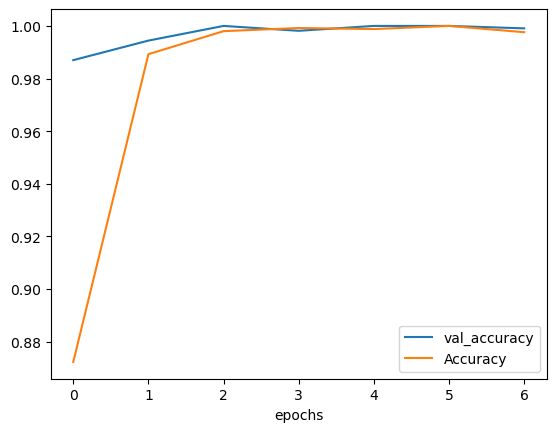

In [15]:
#dibujamos el entrenamiento
import matplotlib.pyplot as plt 
accuracy = h.history['accuracy']
val_accuracy = h.history['val_accuracy']
n_epochs = len(val_accuracy)
plt.plot(range(0, n_epochs), val_accuracy, label='val_accuracy')
plt.plot(range(0, n_epochs), accuracy, label="Accuracy")

plt.xlabel('epochs')
plt.legend()

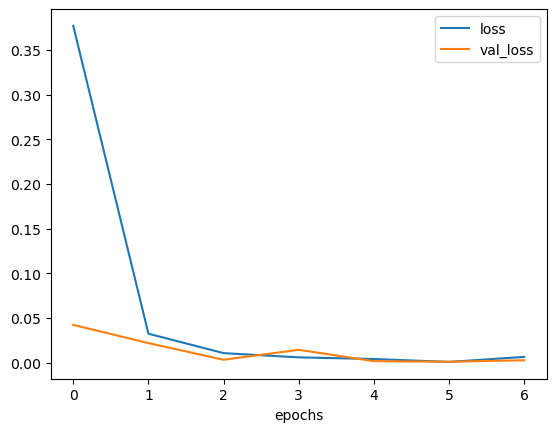

In [16]:
import matplotlib.pyplot as plt 
loss = h.history['loss']
val_loss = h.history['val_loss']
n_epochs = len(loss)
plt.plot(range(0, n_epochs), loss, label='loss')
plt.plot(range(0, n_epochs), val_loss, label="val_loss")

plt.xlabel('epochs')
plt.legend()

In [12]:
test_loss, test_acc = modelo.evaluate(val)
print("Test loss", test_loss)
print("Test accuracy", test_acc)

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9991 - loss: 0.0027
Test loss 0.0027119219303131104
Test accuracy 0.9990706443786621


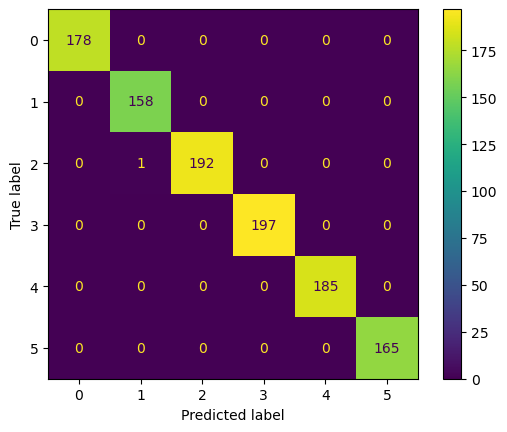

In [13]:
# Obtener todas las etiquetas reales del dataset de validación
y_true = []
for batch in val:
    labels = batch[1].numpy()
    y_true.extend(np.argmax(labels, axis=1))

# Hacer predicciones sobre el dataset de validación
y_pred = []
for batch in val:
    preds = modelo.predict(batch[0], verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# Matriz de confusión
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
mcd = ConfusionMatrixDisplay(cm)
mcd.plot()

In [14]:
modelo.save("adivinador_dedos_dmr.keras")